In [8]:
# Decision Trees 

import os 
from pathlib import Path

import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from helper import * 

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, train_test_split, GridSearchCV
from sklearn.metrics import recall_score, accuracy_score, f1_score, roc_auc_score, roc_curve, classification_report, confusion_matrix

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

current_dir = Path.cwd()  
PROJECT_ROOT = current_dir.parent.parent

df = pd.read_csv(PROJECT_ROOT/'data'/'processed'/'Cleaned_csv.csv')

df = df.drop(labels=['Unnamed: 0'], axis=1)
df = df.rename(columns=lambda x: x.replace('remainder__', ''))
df.head()

,encoder__City_Los Angeles,encoder__City_Other,encoder__City_San Diego,encoder__City_San Francisco,encoder__Gender_Female,encoder__Gender_Male,encoder__Senior Citizen_No,encoder__Senior Citizen_Yes,encoder__Dependents_No,encoder__Dependents_Yes,...,encoder__Paperless Billing_Yes,encoder__Payment Method_Bank transfer (automatic),encoder__Payment Method_Credit card (automatic),encoder__Payment Method_Electronic check,encoder__Payment Method_Mailed check,Tenure Months,Monthly Charges,Total Charges,Churn Value,CLTV
0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,2.0,53.85,108.15,1.0,3239.0
1,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,1.0,0.0,0.0,1.0,0.0,2.0,70.70,151.65,1.0,2701.0
2,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,1.0,0.0,0.0,1.0,0.0,8.0,99.65,820.50,1.0,5372.0
3,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,1.0,0.0,0.0,1.0,0.0,28.0,104.80,3046.05,1.0,5003.0
4,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,...,1.0,1.0,0.0,0.0,0.0,49.0,103.70,5036.30,1.0,5340.0


In [9]:
X = df.drop(labels=['Churn Value'], axis=1)
y = df['Churn Value']

tree = DecisionTreeClassifier() 

pipeline = build_PipieLine(tree, X, y)

pipeline.train()

Pipeline(steps=[('smote', SMOTE(random_state=42)),
                ('model_DecisionTreeClassifier', DecisionTreeClassifier())])

Accuracy: 0.740
Recall: 0.527
F1: 0.518


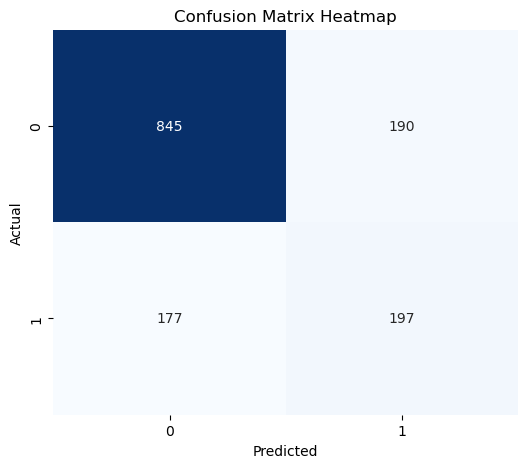

In [10]:
pipeline.evaluate(pipeline.pipeline)

In [11]:
param_grids = {
    f'model_{tree.__class__.__name__}__criterion':['gini', 'entropy', 'log_loss'],
    f'model_{tree.__class__.__name__}__splitter': ['best', 'random'],
    f'model_{tree.__class__.__name__}__max_depth': [5, 10, 15, 20, 50],
    f'model_{tree.__class__.__name__}__min_samples_split': [2, 4],
     f'model_{tree.__class__.__name__}__class_weight': ['balanced']
}

cv = pipeline.cv(param_grids)


C:\Users\andre\anaconda3\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Accuracy: 0.753
Recall: 0.730
F1: 0.611


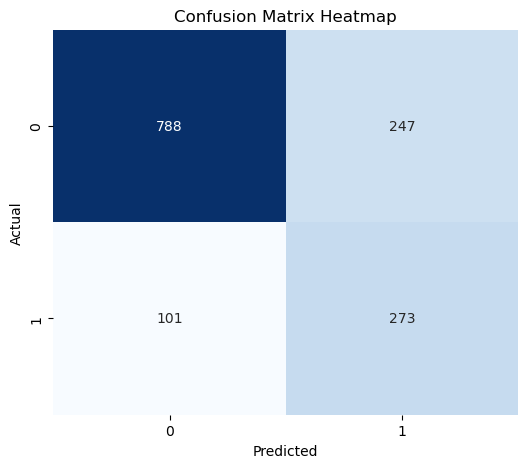

In [12]:
pipeline.evaluate(cv)

In [14]:
y_pred = cv.predict(pipeline.X_test)

accuracy = accuracy_score(pipeline.y_test, y_pred)
recall = recall_score(pipeline.y_test, y_pred)
f1 = f1_score(pipeline.y_test, y_pred)

models_df = pd.DataFrame({
    'Model': ['Decision Trees'],
    'Accuracy': [round(accuracy, 3)],
    'Recall': [round(recall, 3)],
    'F1':[round(f1,3)]
})

models_df.to_csv(PROJECT_ROOT/'data'/'processed'/'model_results.csv', mode="a", index=False, header=False)

In [16]:
models_df = pd.read_csv(PROJECT_ROOT/'data'/'processed'/'model_results.csv')
models_df.head()

,Model,Accuracy,Recall,F1
0,Baseline Model (Logistic Regression),0.751,0.808,0.648
1,Decision Trees,0.753,0.730,0.611
